In [3]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
import os

In [11]:
root_dir = 'D:/Rishikesh/BCT/VI/Minor/rooftop-detection/'

In [66]:
# Load preprocessed training images and labels
train_input_dir = os.path.join(root_dir, 'data/raw/train_images')

train_images = []
train_labels = []

image_filenames = sorted([f for f in os.listdir(train_input_dir) if f.lower().endswith('.png')])
label_filenames = sorted([f for f in os.listdir(train_input_dir) if f.lower().endswith('.png')])

for image_filename, label_filename in zip(image_filenames, label_filenames):
    image_path = os.path.join(train_input_dir, image_filename)
    label_path = os.path.join(train_input_dir, label_filename)
    
    image = cv2.imread(image_path)
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    
    train_images.append(image)
    train_labels.append(label)

# Load preprocessed validation images and labels
val_input_dir = os.path.join(root_dir, 'data/raw/train_labels')

val_images = []
val_labels = []

image_filenames = sorted([f for f in os.listdir(val_input_dir) if f.lower().endswith('.png')])
label_filenames = sorted([f for f in os.listdir(val_input_dir) if f.lower().endswith('.png')])

for image_filename, label_filename in zip(image_filenames, label_filenames):
    image_path = os.path.join(val_input_dir, image_filename)
    label_path = os.path.join(val_input_dir, label_filename)
    
    image = cv2.imread(image_path)
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
    
    val_images.append(image)
    val_labels.append(label)

# Load preprocessed test images
test_input_dir = os.path.join(root_dir, 'data/raw/test_images')

test_images = []

image_filenames = sorted([f for f in os.listdir(test_input_dir) if f.lower().endswith('.png')])

for image_filename in image_filenames:
    image_path = os.path.join(test_input_dir, image_filename)
    image = cv2.imread(image_path)
    test_images.append(image)

In [21]:
# Normalize pixel values
train_images = np.array(train_images) / 255.0
train_labels = np.array(train_labels) / 255.0

val_images = np.array(val_images) / 255.0
val_labels = np.array(val_labels) / 255.0

test_images = np.array(test_images) / 255.0

## Network Architecture

U-Net, CNN architechture suitable for image segmentation task; takes satellite image as input and generates binary mask where the roofs' boundaries are represented as white pixels (255) and the rest of the image as black (0).

Each step in the U-Net model architecture contributes to the image segmentation task of boundary detection in the following ways:

1. **Contracting Path**: The contracting path consists of a series of convolutional layers followed by max pooling layers. This path helps in capturing low-level features and spatial information from the input image. The convolutional layers extract local patterns and features, while the max pooling layers downsample the feature maps, reducing the spatial dimensions while increasing the receptive field. This allows the model to learn hierarchical representations of the input image, gradually capturing more abstract and higher-level features.

2. **Bottleneck**: The bottleneck layer is a central component of the U-Net architecture. It consists of convolutional layers applied to the output of the contracting path. This layer helps in capturing and encoding the most abstract features and information from the input image. It acts as a bridge between the contracting and expansive paths, allowing the model to capture and retain important contextual information.

3. **Expansive Path**: The expansive path is responsible for upsampling the feature maps and recovering the spatial information lost during the contracting path. It consists of upsampling layers followed by convolutional layers. The upsampling layers increase the spatial dimensions of the feature maps, while the convolutional layers refine the features and capture more detailed information. Additionally, the expansive path incorporates skip connections, where the feature maps from the contracting path are concatenated with the corresponding feature maps in the expansive path. These skip connections help in preserving spatial information and improving the model's ability to localize boundaries accurately.

4. **Output Layer**: The output layer is a single convolutional layer with a sigmoid activation function. It produces a binary mask representing the predicted boundaries for each pixel in the input image. The sigmoid activation function maps the output values to the range [0, 1], where higher values indicate the presence of a boundary. The output mask can be further processed and thresholded to generate a clear boundary map for the image.

In [22]:
from tensorflow.keras import layers

def unet():
    inputs = keras.Input(shape=(None, None, 3))

    # Contracting Path
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # Bottleneck
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)

    # Expansive Path
    up1 = layers.Conv2DTranspose(256, 2, strides=(2, 2), padding='same')(conv4)
    up1 = layers.concatenate([up1, conv3])
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(up1)
    conv5 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv5)

    up2 = layers.Conv2DTranspose(128, 2, strides=(2, 2), padding='same')(conv5)
    up2 = layers.concatenate([up2, conv2])
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(up2)
    conv6 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv6)

    up3 = layers.Conv2DTranspose(64, 2, strides=(2, 2), padding='same')(conv6)
    up3 = layers.concatenate([up3, conv1])
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(up3)
    conv7 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv7)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    return keras.Model(inputs=inputs, outputs=outputs)


### Model Details

* Optimizer: [Adam](https://keras.io/api/optimizers/adam/), a stochastic gradient descent method that is considered good for boundary detection. Other options are: RMSprop, SGD.
* Loss: [BinaryCrossentropy](https://keras.io/api/losses/probabilistic_losses/#binarycrossentropy-class), a pixel-wise loss function, which compares the predicted and ground truth boundary masks on a pixel level; useful for boundary detection.
* Metrics: [BinaryAccuracy](https://keras.io/api/metrics/accuracy_metrics/#binaryaccuracy-class) [or BinaryCrossentropy], since we are comparing against labels which have binary values.
```

In [23]:
optimizer = 'adam' # good for boundary detection; other options: RMSprop, SGD
loss = 'binary_crossentropy'
metrics = ['binary_accuracy'] # other options: binary_crossentropy

In [24]:
model = unet()
model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, None, None,  0           []                               
                                 3)]                                                              
                                                                                                  
 conv2d (Conv2D)                (None, None, None,   1792        ['input_1[0][0]']                
                                64)                                                               
                                                                                                  
 conv2d_1 (Conv2D)              (None, None, None,   36928       ['conv2d[0][0]']                 
                                64)                                                           

In [25]:
batch_size = 32 # increased in powers of 2, from 8, until statistical fluctuations between epochs stabilised
epochs = 100 # increased from 20, until the model showed signs of overfitting (train/valid curves started diverging)
validation_split = 0.3

In [26]:
# Assuming you have loaded your training data into `train_images` and `train_masks` arrays
history = model.fit(train_images, train_labels, batch_size=batch_size, epochs=epochs, validation_split=validation_split)

Epoch 1/100
1/1 [==============================] - 36s 36s/step - loss: 0.6935 - binary_accuracy: 0.0358 - val_loss: 0.6791 - val_binary_accuracy: 0.1187
Epoch 2/100
1/1 [==============================] - 26s 26s/step - loss: 0.6764 - binary_accuracy: 0.0979 - val_loss: 0.6629 - val_binary_accuracy: 0.1187
Epoch 3/100
1/1 [==============================] - 26s 26s/step - loss: 0.6507 - binary_accuracy: 0.0979 - val_loss: 1.0119 - val_binary_accuracy: 0.1187
Epoch 4/100
1/1 [==============================] - 25s 25s/step - loss: 0.9100 - binary_accuracy: 0.0979 - val_loss: 0.6671 - val_binary_accuracy: 0.1187
Epoch 5/100
1/1 [==============================] - 24s 24s/step - loss: 0.6468 - binary_accuracy: 0.0979 - val_loss: 0.6627 - val_binary_accuracy: 0.1187
Epoch 6/100
1/1 [==============================] - 28s 28s/step - loss: 0.6545 - binary_accuracy: 0.0979 - val_loss: 0.6679 - val_binary_accuracy: 0.1187
Epoch 7/100
1/1 [==============================] - 25s 25s/step - loss: 0.66

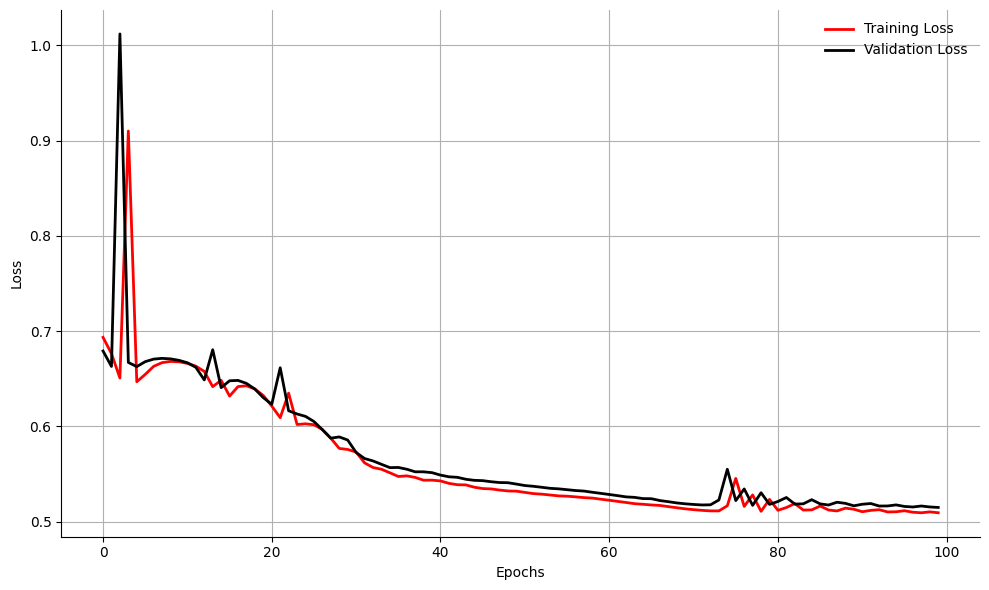

In [105]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']

c = ['r', 'k']
lw, ms, marker = 2, 3, ''

# Plotting the loss curve
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(train_loss, label='Training Loss', color=c[0], marker=marker, ms=ms, lw=lw)
ax.plot(val_loss, label='Validation Loss', color=c[1], marker=marker, ms=ms, lw=lw)
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.spines[['right', 'top']].set_visible(False)
ax.legend(frameon=False)
ax.grid()
plt.tight_layout()
plt.show()

In [ ]:
# Save the entire model
model.save(root_dir + '/models/unet_final_2.h5')